In [1]:
from pathlib import Path

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from aeon.classification.feature_based import Catch22Classifier
from aeon.regression.feature_based import Catch22Regressor
from aeon.transformations.collection.feature_based import Catch22
from sklearn.model_selection import cross_validate

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [5]:

def print_cv_results(cv_results):
    for key, value in cv_results.items():
        if key.startswith('test'):
            print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

In [6]:
data_dir = Path('../../results')

We run the Catch22 classifier/regressor on the whole training set without hyperparameter tuning and check feature importance.

Catch22 classifier/regressor use a Random Forest as estimator by default.

In [22]:
c22_transformer = Catch22(features='all', catch24=True, use_pycatch22=True)
feature_names = c22_transformer.get_features_arguments
feature_names

['DN_HistogramMode_5',
 'DN_HistogramMode_10',
 'CO_f1ecac',
 'CO_FirstMin_ac',
 'CO_HistogramAMI_even_2_5',
 'CO_trev_1_num',
 'MD_hrv_classic_pnn40',
 'SB_BinaryStats_mean_longstretch1',
 'SB_TransitionMatrix_3ac_sumdiagcov',
 'PD_PeriodicityWang_th0_01',
 'CO_Embed2_Dist_tau_d_expfit_meandiff',
 'IN_AutoMutualInfoStats_40_gaussian_fmmi',
 'FC_LocalSimple_mean1_tauresrat',
 'DN_OutlierInclude_p_001_mdrmd',
 'DN_OutlierInclude_n_001_mdrmd',
 'SP_Summaries_welch_rect_area_5_1',
 'SB_BinaryStats_diff_longstretch0',
 'SB_MotifThree_quantile_hh',
 'SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1',
 'SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1',
 'SP_Summaries_welch_rect_centroid',
 'FC_LocalSimple_mean3_stderr',
 'Mean',
 'StandardDeviation']

In [28]:
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)

In [29]:
train_X = train[[str(i) for i in range(100)]].values.reshape(len(train), 1, 100)

We use the C implementation of the catch 22 transformer in order to speed up the process.

In [30]:
clf = Catch22Classifier(use_pycatch22=True)
regressor = Catch22Regressor(use_pycatch22=True)

We need this tranformed df to inspect features.

In [32]:
train_c22 = c22_transformer.fit_transform(train_X)
train_c22 = pd.DataFrame(train_c22, columns=feature_names)
train_c22.index = train.index
train_c22

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr,Mean,StandardDeviation
id,,,,,,,,,,,,,,,,,,,,,
tt10855768,-0.333098,-0.569656,3.292878,9.0,0.231946,-0.049935,0.767677,8.0,0.062500,13.0,...,0.550,0.817875,12.0,1.717638,0.314286,0.314286,0.392699,0.585646,640039.02,7.702276e+05
tt3766354,-0.204680,-0.447203,5.038619,10.0,0.384456,-0.035084,0.676768,20.0,0.074074,13.0,...,0.480,0.855605,10.0,1.544890,0.171429,0.600000,0.147262,0.370692,1975049.87,2.726351e+06
tt6791096,-0.235415,-0.476199,4.240450,9.0,0.381551,-0.037754,0.535354,20.0,0.074074,13.0,...,0.475,0.845503,12.0,1.499035,0.171429,0.600000,0.196350,0.443455,947198.80,1.275064e+06
tt1821549,-0.968873,-0.759462,3.452775,8.0,0.382275,0.029799,0.787879,18.0,0.002604,14.0,...,-0.550,0.877449,7.0,1.670886,0.828571,0.742857,0.392699,0.713396,131952.38,8.603752e+04
tt7144666,-0.305268,-0.580867,5.878877,9.0,0.412512,-0.022879,0.676768,25.0,0.074074,14.0,...,0.555,0.843426,6.0,1.452820,0.171429,0.600000,0.098175,0.338991,1710723.00,1.823184e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tt7668870,-0.511009,-0.701741,4.263695,8.0,0.399966,0.106980,0.707071,13.0,0.080000,14.0,...,0.450,0.915131,10.0,1.543322,0.800000,0.828571,0.196350,0.632183,527703.77,5.610023e+05
tt8884430,-1.012251,-0.308258,3.125186,7.0,0.266802,-0.021545,0.777778,11.0,0.005540,14.0,...,-0.570,0.880690,9.0,1.690194,0.200000,0.514286,0.441786,0.766044,43593.67,2.696540e+04
tt9883996,-0.279530,-0.495243,5.479613,8.0,0.435485,-0.029595,0.424242,33.0,0.074074,15.0,...,0.490,0.892418,9.0,1.265352,0.400000,0.600000,0.049087,0.446650,55202.20,7.524475e+04


## Action

In [11]:
train_y = train['action']
results = cross_validate(clf, train_X, train_y, scoring=('f1', 'precision', 'recall', 'average_precision'))
print_cv_results(results)

f1: 0.53 (0.03)
precision: 0.67 (0.05)
recall: 0.44 (0.03)
average_precision: 0.66 (0.04)


In [12]:
clf.fit(train_X, train_y)

Catch22Classifier(use_pycatch22=True)

Text(0, 0.5, '')

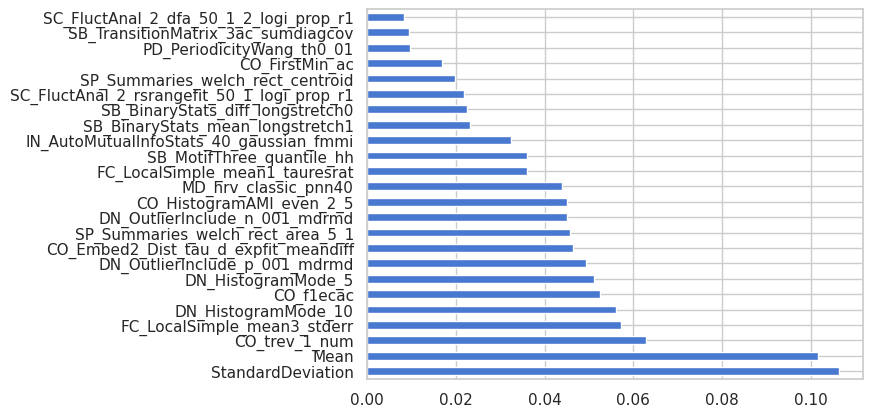

In [13]:
feat_importances = pd.DataFrame(zip(feature_names, clf.estimator_.feature_importances_)).set_index(0)
feat_importances.sort_values(1, ascending=False).plot.barh(legend=False)
plt.ylabel('')

## Rating Category

In [14]:
train_y = train['rating_category']
results = cross_validate(clf, train_X, train_y, scoring=('f1_macro', 'accuracy'))
print_cv_results(results)

f1_macro: 0.30 (0.01)
accuracy: 0.46 (0.01)


In [15]:
clf.fit(train_X, train_y)

Catch22Classifier(use_pycatch22=True)

Text(0, 0.5, '')

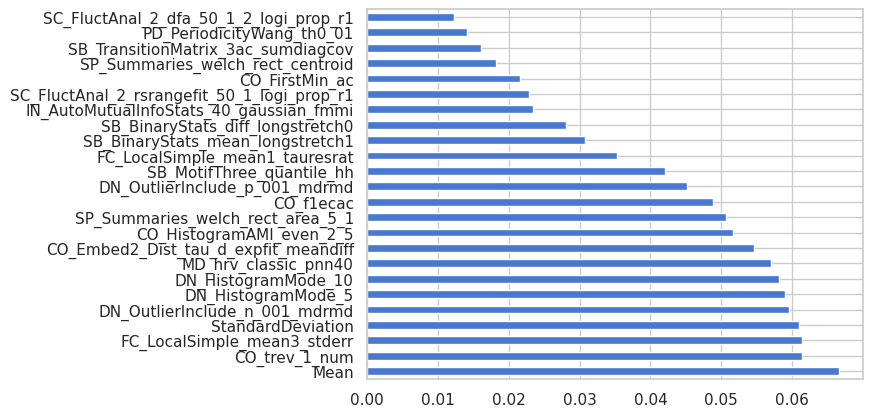

In [16]:
feat_importances = pd.DataFrame(zip(feature_names, clf.estimator_.feature_importances_)).set_index(0)
feat_importances.sort_values(1, ascending=False).plot.barh(legend=False)
plt.ylabel('')

For the two classifiers, the top 4 features are the same (although in different orders). In addition to mean and standard deviation
- `CO_trev_1_num` is a non linear autocorrelation feature: it will be close to zero for time series for which the distribution of successive decreases in the time series matches the distribution of successive increases, but will be positive if increases tend to be larger in magnitude and negative if decreases tend to be larger in magnitude.
- `FC_LocalSimple_mean3_stderr` a 3-point mean forecasting is performed and standard deviation of the residuals is computed. It is higher when sampling rate is low with respect to the timescale of the dynamics variations.

In [93]:
def plot_extreme_values(feature_name):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].plot(train_X[train_c22[feature_name].argmin()][0])
    feat_value = train_c22[feature_name].min()
    axs[0].set_title(f'{train.iloc[train_c22[feature_name].argmin()]['title']}: {feat_value:.2f}')


    axs[1].plot(train_X[train_c22[feature_name].argmax()][0])
    feat_value = train_c22[feature_name].max()
    axs[1].set_title(f'{train.iloc[train_c22[feature_name].argmax()]['title']}: {feat_value:.2f}')


    fig.suptitle(feature_name)

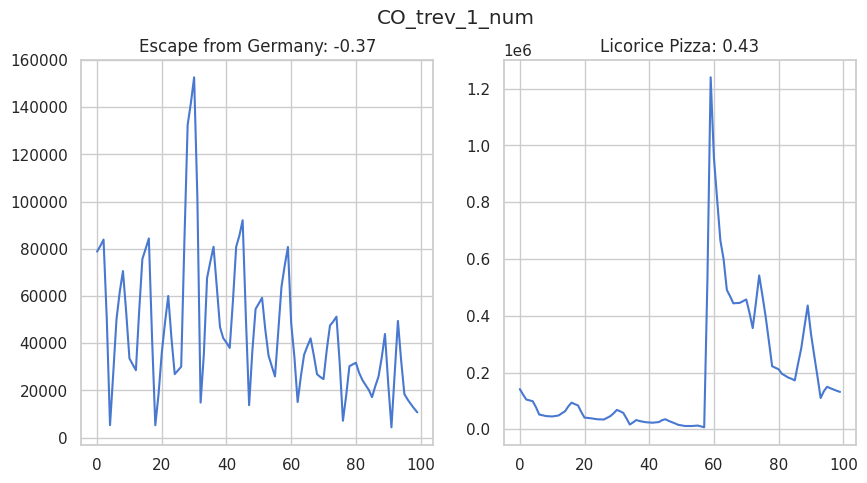

In [94]:
plot_extreme_values('CO_trev_1_num')

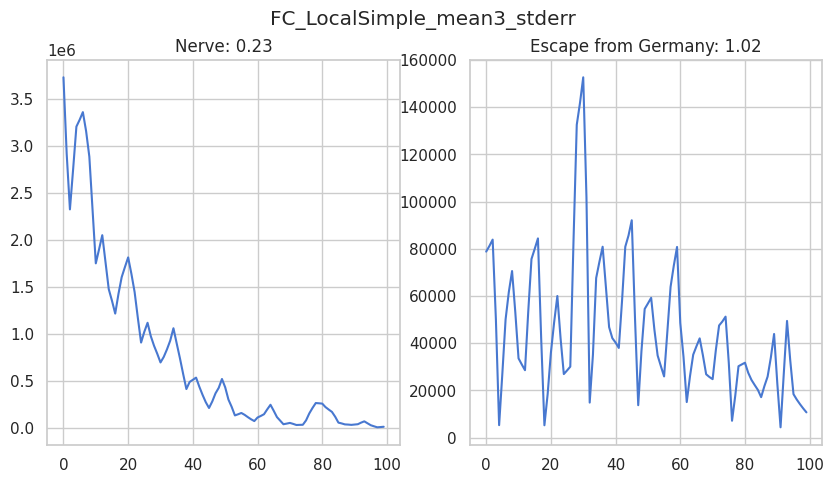

In [95]:
plot_extreme_values('FC_LocalSimple_mean3_stderr')

## Rating (regression)

In [96]:
train_y = train['rating']
results = cross_validate(regressor, train_X, train_y, scoring=('neg_mean_squared_error', 'r2'))
print_cv_results(results)

neg_mean_squared_error: -0.58 (0.07)
r2: 0.26 (0.11)


In [97]:
regressor.fit(train_X, train_y)

Catch22Regressor(use_pycatch22=True)

Text(0, 0.5, '')

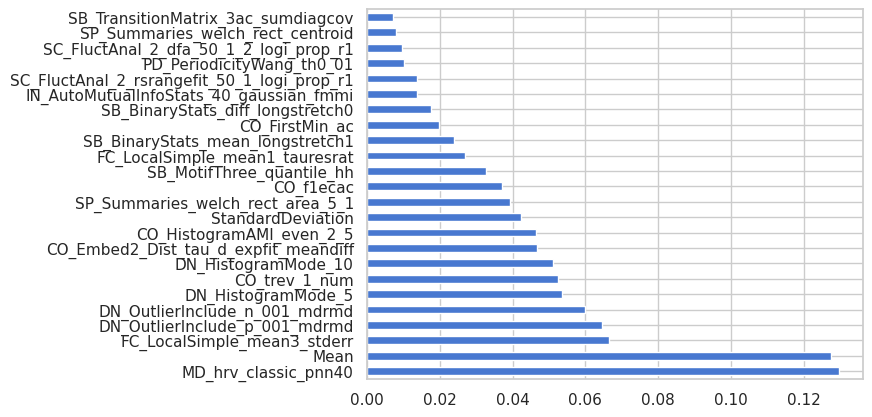

In [98]:
feat_importances = pd.DataFrame(zip(feature_names, regressor._estimator.feature_importances_)).set_index(0)
feat_importances.sort_values(1, ascending=False).plot.barh(legend=False)
plt.ylabel('')

Mean is always among the top features.

`FC_LocalSimple_mean3_stderr` is also present. In addition to these we have two features related to extreme event timing (positive and negative outliers). These features take values near to 0 when extreme events are approximately equally likely to occurr anywhere on the time series, -1 when they occurr at the start of the time series and 1 when they occurr at the end.

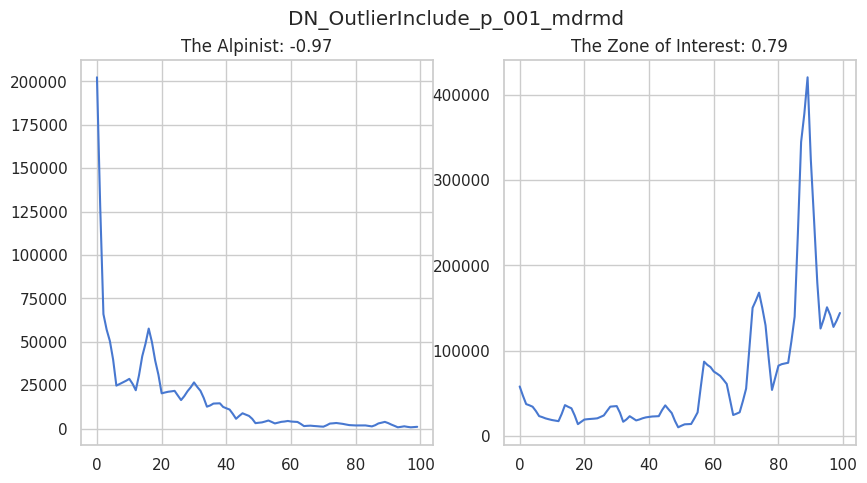

In [99]:
plot_extreme_values('DN_OutlierInclude_p_001_mdrmd')

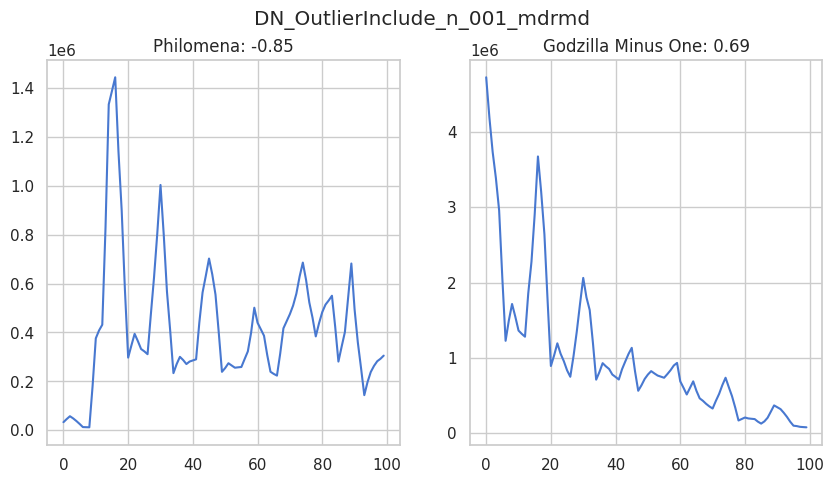

In [100]:
plot_extreme_values('DN_OutlierInclude_n_001_mdrmd')